In [1]:
import numpy as np
# import cupy as cp
import pandas as pd
import multiprocessing as mp
import itertools
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import rc
rc('animation', html='jshtml', embed_limit=500.0)

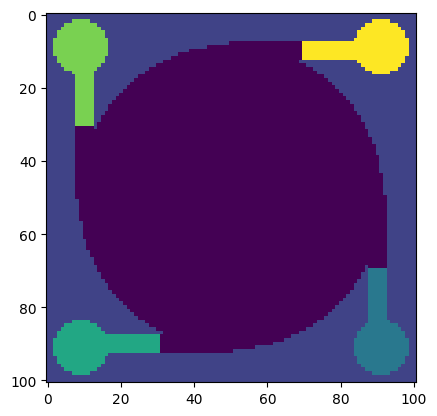

In [2]:
def generate_node(width, height, node_radius, channel_width):
  node = np.zeros((width, height), dtype=np.int8)
  center = width // 2
  body_radius = center - node_radius
  small_center = width - node_radius - 2
  node_x = np.round(np.sqrt(body_radius**2 - (body_radius - channel_width)**2))

  # Draws the big circle
  for x in np.arange(width):
    for y in np.arange(height):
        dist = np.round(np.sqrt((x - center)**2 + (y - center)**2))
        if (dist < body_radius):
          node[x][y] = -1

  # Draws the lobes
  for side in np.arange(1, 5):
    # Draws a rectangular channel
    for y in np.arange(center + body_radius, center + body_radius - channel_width, -1):
      for x in np.arange(center, center + body_radius):
        if (x < center + node_x):
          # Overlaps with the big circle
          node[x][y] = -1
        else:
          # Extended region
          node[x][y] = side

    #Draws a small circle
    for x in np.arange(width):
      for y in np.arange(height):
        dist = np.round(np.sqrt((x - small_center)**2 + (y - small_center)**2))
        if (dist < node_radius):
          node[x][y] = side

    node = np.rot90(node)
  return node

node = generate_node(width=101, height=101, node_radius=8, channel_width=5)
# plt.imshow(node.view(dtype=bool) == np.rot90(node).view(dtype=bool))
plt.imshow(node)

In [3]:
def run_simulation(width, height, node_radius, channel_width,
                   alpha_pip, alpha_enzyme, timestep, patch_area,
                   k_mkon, p_mkon, k_koff, p_koff,
                   k_mkcat, p_mkcat, k_mKm, p_mKm,
                   total_kinases, total_pptases,
                   run_num=0, show_map=False):
  num_frames = 50000

  node = generate_node(width=width, height=height, node_radius=node_radius, channel_width=channel_width)
  in_cell = node.view(dtype=bool)
  pip = np.full(node.shape, 0.5, dtype=np.float16) - ~in_cell
  kinases = np.zeros(node.shape, dtype=np.int16)
  pptases = np.zeros(node.shape, dtype=np.int16)
  soln_kinases = total_kinases
  soln_pptases = total_pptases

  k_Poff = k_koff * timestep
  p_Poff = p_koff * timestep
  if k_Poff > 1:
    raise ValueError(f"k_Poff of {k_Poff} exceeds 1, reduce timestep")
  if p_Poff > 1:
    raise ValueError(f"p_Poff of {p_Poff} exceeds 1, reduce timestep")
  Pmove = (4 * alpha_enzyme * timestep) / patch_area
  if Pmove > 1:
    raise ValueError(f"Pmove of {Pmove} exceeds 1, enzyme movement unstable")

  rng = np.random.default_rng()
  adj_tuples = [(-1, 0), (1, 0), (0, -1), (0, 1)]
  # adj_permuts = np.array(list(itertools.permutations(adj_tuples)))

  # #flattening the index list isn't strictly necessary but not doing so gives me a migraine
  # x_idx, y_idx = np.indices(node.shape)
  # x_idx = np.ravel(x_idx)
  # y_idx = np.ravel(y_idx)
  # x_four_idx = np.repeat(x_idx[np.newaxis], 4, axis=0)
  # y_four_idx = np.repeat(y_idx[np.newaxis], 4, axis=0)
  avg_body_pip = lambda node, pip: np.mean(pip, where=node == -1)
  avg_node_pip = lambda node, pip, side: np.mean(pip, where=node == side)
  avg_node_pip_list = lambda node, pip: np.array(
      [avg_node_pip(node, pip, side) for side in np.arange(1, 5)])
  avg_all_node_pip = lambda node, pip: np.mean(pip, where=node > 0)
  num_polar = lambda node, pip: np.count_nonzero(avg_node_pip_list(node, pip) > np.max([2 * avg_body_pip(node, pip), 0.3]))
  frame_hist = []
  soln_kinases_hist = []
  soln_pptases_hist = []
  body_pip_hist = []
  node_pip_hist = [[], [], [], []]
  all_node_pip_hist = []
  anim = None


  if show_map:
    fig, ax = plt.subplots()
    ims = []
    im = ax.imshow(pip, cmap="twilight_shifted", vmin=0, vmax=1)
    im = ax.imshow(pip, alpha=in_cell.astype(float), vmin=0, vmax=1)
    fig.colorbar(im, ax=ax, label='PIP2 proportion')

  for frame_i in np.arange(1, num_frames + 1):
    ##unbind
    kinases_to_unbind = rng.binomial(kinases, k_Poff)
    pptases_to_unbind = rng.binomial(pptases, p_Poff)
    kinases -= kinases_to_unbind
    pptases -= pptases_to_unbind
    soln_kinases += np.sum(kinases_to_unbind)
    soln_pptases += np.sum(pptases_to_unbind)

    ##bind
    k_Pon_thresh = rng.random()
    p_Pon_thresh = rng.random()

    #Calculate, store k_Pon (kinase binding probability) & p_Pon (phosphatase binding probability)
    k_Pon = in_cell * k_mkon * pip * patch_area * timestep * soln_kinases / total_kinases
    p_Pon = in_cell * p_mkon * (1 - pip) * patch_area * timestep * soln_pptases / total_pptases
    if np.sum(k_Pon) > 1:
      raise ValueError(f"Total k_Pon of {np.sum(k_Pon)} exceeds 1, binding uneven")
    if np.sum(p_Pon) > 1:
      raise ValueError(f"Total p_Pon of {np.sum(p_Pon)} exceeds 1, binding uneven")

    k_Pon_running_sum = np.cumsum(k_Pon)
    p_Pon_running_sum = np.cumsum(p_Pon)
    k_Pon_above_thresh = (k_Pon_running_sum > k_Pon_thresh)
    p_Pon_above_thresh = (p_Pon_running_sum > p_Pon_thresh)

    if (k_Pon_above_thresh).any():
      k_bind_x, k_bind_y = np.unravel_index(np.argmax(k_Pon_above_thresh), node.shape)
      kinases[k_bind_x][k_bind_y] += 1
      soln_kinases -= 1
    if (p_Pon_above_thresh).any():
      p_bind_x, p_bind_y = np.unravel_index(np.argmax(p_Pon_above_thresh), node.shape)
      pptases[p_bind_x][p_bind_y] += 1
      soln_pptases -= 1

    ##convert
    #Calculate enzyme densities (enzymes per unit area)
    kinase_density = kinases / patch_area
    pptase_density = pptases / patch_area

    #Michaelis-Menten kinetics
    kinase_contrib = k_mkcat * kinase_density * (1 - pip) / (k_mKm + (1 - pip))
    #Kinase converts PIP1->PIP2 (increases X)
    #Phosphatase converts PIP2->PIP1 (decreases X)
    pptase_contrib = -p_mkcat * pptase_density * pip / (p_mKm + pip)

    dpip = (kinase_contrib + pptase_contrib) * timestep
    pip = np.maximum(0, np.minimum(1, pip + dpip))


    ##move
    new_kinases = kinases.copy()
    new_pptases = pptases.copy()

    has_kinase_idx = kinases.nonzero()
    for x, y in np.repeat(has_kinase_idx, kinases[has_kinase_idx], axis=1).T:
      if rng.random() < Pmove:
        moved = False
        rng.shuffle(adj_tuples)
        for dx, dy in adj_tuples:
          if (not moved
              and 0 <= x + dx < node.shape[0]
              and 0 <= y + dy < node.shape[1]
              and node[x + dx][y + dy]):
            new_kinases[x + dx][y + dy] += 1
            new_kinases[x][y] -= 1
            moved = True
    for x, y in np.transpose(pptases.nonzero()):
      if rng.random() < Pmove:
        moved = False
        rng.shuffle(adj_tuples)
        for dx, dy in adj_tuples:
          if (not moved
              and 0 <= x + dx < node.shape[0]
              and 0 <= y + dy < node.shape[1]
              and node[x + dx][y + dy]):
            new_pptases[x + dx][y + dy] += 1
            new_pptases[x][y] -= 1
            moved = True

    # # Probability of moving (from NetLogo)
    # k_to_move = rng.binomial(np.ravel(kinases), Pmove)
    # p_to_move = rng.binomial(np.ravel(pptases), Pmove)

    # k_adj_x, k_adj_y = rng.choice(adj_permuts, node.size).T + (x_four_idx, y_four_idx)
    # p_adj_x, p_adj_y = rng.choice(adj_permuts, node.size).T + (x_four_idx, y_four_idx)

    # for i in np.arange(4):
    #   if (k_to_move.any() | p_to_move.any()):
    #     k_adj_in_bounds = ((k_adj_x[i] >= 0) & (k_adj_x[i] < node.shape[0])
    #       & (k_adj_y[i] >= 0) & (k_adj_y[i] < node.shape[1]))
    #     p_adj_in_bounds = ((p_adj_x[i] >= 0) & (p_adj_x[i] < node.shape[0])
    #       & (p_adj_y[i] >= 0) & (p_adj_y[i] < node.shape[1]))
    #     k_adj_x_bounded = k_adj_x[i][k_adj_in_bounds]
    #     k_adj_y_bounded = k_adj_y[i][k_adj_in_bounds]
    #     p_adj_x_bounded = p_adj_x[i][p_adj_in_bounds]
    #     p_adj_y_bounded = p_adj_y[i][p_adj_in_bounds]

    #     valid_k_adj = np.zeros(node.size, dtype=bool)
    #     valid_p_adj = np.zeros(node.size, dtype=bool)
    #     valid_k_adj[k_adj_in_bounds] = in_cell[k_adj_x_bounded, k_adj_y_bounded]
    #     valid_p_adj[p_adj_in_bounds] = in_cell[p_adj_x_bounded, p_adj_y_bounded]

    #     kinase_diff = k_to_move * valid_k_adj
    #     pptase_diff = p_to_move * valid_p_adj
    #     np.add.at(new_kinases, (k_adj_x_bounded, k_adj_y_bounded), kinase_diff[k_adj_in_bounds])
    #     np.add.at(new_pptases, (p_adj_x_bounded, p_adj_y_bounded), pptase_diff[p_adj_in_bounds])
    #     new_kinases -= np.reshape(kinase_diff, node.shape)
    #     new_pptases -= np.reshape(pptase_diff, node.shape)
    #     k_to_move = k_to_move & (~kinase_diff)
    #     p_to_move = p_to_move & (~pptase_diff)

    # Apply updates
    kinases = new_kinases
    pptases = new_pptases

    ##diffuse
    # FTCS scheme: x_new = x(1 - 4α·n/4) + Σ(neighbors)·α = x + α•(Σ(neighbors) - x·n)
    if alpha_pip >= 0.25:
      raise ValueError(f"alpha_pip of {alpha_pip} exceeds 0.25, diffusion unstable")
    new_pip = pip.copy()
    new_pip[   1: ] += (in_cell[   1: ] * in_cell[   :-1]
                        * alpha_pip * (pip[   :-1] - pip[   1: ]))
    new_pip[   :-1] += (in_cell[   :-1] * in_cell[   1: ]
                        * alpha_pip * (pip[   1: ] - pip[   :-1]))
    new_pip[:, 1: ] += (in_cell[:, 1: ] * in_cell[:, :-1]
                        * alpha_pip * (pip[:, :-1] - pip[:, 1: ]))
    new_pip[:, :-1] += (in_cell[:, :-1] * in_cell[:, 1: ]
                        * alpha_pip * (pip[:, 1: ] - pip[:, :-1]))
    pip = new_pip

    if frame_i % 5000 == 0:
      frame_hist.append(frame_i)
      soln_kinases_hist.append(soln_kinases)
      soln_pptases_hist.append(soln_pptases)
      body_pip_hist.append(avg_body_pip(node, pip))
      for i in np.arange(4):
        node_pip_hist[i].append(avg_node_pip(node, pip, i + 1))
      all_node_pip_hist.append(avg_all_node_pip(node, pip))
    if frame_i % 1000 == 0 and run_num == 0:
      print(f"Frame {frame_i} - "
      f"Run {run_num} - "
      f"Kinases bound: {total_kinases - soln_kinases}/{total_kinases} - "
      f"Pptases bound: {total_pptases - soln_pptases}/{total_pptases} - "
      f"Avg Body PIP2: {np.round(avg_body_pip(node, pip), 3)} - "
      f"Avg Node PIP2: {np.round(avg_node_pip_list(node, pip), 3)} - "
      f"Num Polarized: {num_polar(node, pip)}")
    if frame_i % 25 == 0 and show_map:
      im = ax.imshow(pip, alpha=in_cell.astype(float), vmin=0, vmax=1, animated=True)
      ims.append([im])
  num_snapshots = len(frame_hist)
  data = {
      'Width': np.full(num_snapshots, width).tolist(),
      'Height': np.full(num_snapshots, height).tolist(),
      'Node Radius': np.full(num_snapshots, node_radius).tolist(),
      'Channel Width': np.full(num_snapshots, channel_width).tolist(),
      'Run Number': np.full(num_snapshots, run_num).tolist(),
      'Frame Number': frame_hist,
      'Total Kinase': np.full(num_snapshots, total_kinases).tolist(),
      'Total Phosphatase': np.full(num_snapshots, total_pptases).tolist(),
      'Timestep': np.full(num_snapshots, timestep).tolist(),
      'Patch Area': np.full(num_snapshots, patch_area).tolist(),
      'alpha_PIP': np.full(num_snapshots, alpha_pip).tolist(),
      'alpha_enzyme': np.full(num_snapshots, alpha_enzyme).tolist(),
      'k_mkon': np.full(num_snapshots, k_mkon).tolist(),
      'p_mkon': np.full(num_snapshots, p_mkon).tolist(),
      'k_koff': np.full(num_snapshots, k_koff).tolist(),
      'p_koff': np.full(num_snapshots, p_koff).tolist(),
      'k_mkcat': np.full(num_snapshots, k_mkcat).tolist(),
      'k_mKm': np.full(num_snapshots, k_mKm).tolist(),
      'p_mkcat': np.full(num_snapshots, p_mkcat).tolist(),
      'p_mKm': np.full(num_snapshots, p_mKm).tolist(),
      'Kinase in Solution': soln_kinases_hist,
      'Phosphatase in Solution': soln_pptases_hist,
      'Average Body X': body_pip_hist,
      'Average Node 1 X': node_pip_hist[0],
      'Average Node 2 X': node_pip_hist[1],
      'Average Node 3 X': node_pip_hist[2],
      'Average Node 4 X': node_pip_hist[3],
      'Average All Nodes X': all_node_pip_hist,
  }
  df = pd.DataFrame(data)
  if show_map:
    plt.show()
    anim = animation.ArtistAnimation(fig, ims, interval=10, blit=True,
                                repeat=True, repeat_delay=1000)
  return df, anim



In [ ]:
# notes on parameters: i chose alpha_pip and alpha_enzyme arbitrarily for
# reasonable diffusion behavior. raising timestep increases enzyme off and on
# framerates, but on rate is constrained by need to have only 1 kinase/pptase
# bind in a frame to avoid awkward situations when limited numbers are left in
# solution, so best to keep it at 0.001. patch_area is set for a reasonable
# off/on framerate ratio; this leaves catalysis rates variable

# print(run_simulation(node, alpha_pip=0.08, alpha_enzyme=0.2,
#                       timestep=0.01, patch_area=0.25,
#                       k_mkon=0.01*10, p_mkon=0.0005*10,
#                       k_koff=4.0*0.1,  p_koff=0.2*0.1,
#                       k_mkcat=0.1*20, p_mkcat=0.4*20,
#                       k_mKm=0.1, p_mKm=0.4,
#                       total_kinases=50, total_pptases=200,
#                       show_map=False))
df, anim = run_simulation(width=100, height=100,
                          node_radius=8, channel_width=5,
                          alpha_pip=0.08, alpha_enzyme=200,
                          timestep=0.001, patch_area=25,
                          k_mkon=0.01, p_mkon=0.0005,
                          k_koff=4.0,  p_koff=0.2,
                          k_mkcat=0.1*20000, p_mkcat=0.4*20000,
                          k_mKm=0.1, p_mKm=0.4,
                          total_kinases=20, total_pptases=200,
                          show_map=False)
# anim = run_simulation(node, alpha_pip=0.08, alpha_enzyme=2,
#                       timestep=0.001, patch_area=0.25,
#                       k_mkon=0.01, p_mkon=0.0005,
#                       k_koff=4.0,  p_koff=0.2,
#                       k_mkcat=0.1*100, p_mkcat=0.4*100,
#                       k_mKm=0.1, p_mKm=0.4,
#                       total_kinases=200, total_pptases=2000,
#                       show_map=True)
anim

In [ ]:
anim.save('animation.mp4', writer='ffmpeg', fps=60)

In [4]:
# num_processes = mp.cpu_count()
num_processes = 100
with mp.Pool(processes=num_processes) as pool:
  args = [(101, 101, 8, 4, 0.08, 200, 0.001, 25, 0.01, 0.0005, 4.0, 0.2, 0.1*20000, 0.4*20000, 0.1, 0.4, 15, 200, run_num) for run_num in np.arange(num_processes)]
  df_list, anim_list = zip(*pool.starmap(run_simulation, args))
full_df = pd.concat(df_list)

Frame 1000 - Run 0 - Kinases bound: 14/15 - Pptases bound: 33/200 - Avg Body PIP2: 0.503 - Avg Node PIP2: [0.433 0.273 0.426 0.254] - Num Polarized: 0
Frame 2000 - Run 0 - Kinases bound: 14/15 - Pptases bound: 73/200 - Avg Body PIP2: 0.301 - Avg Node PIP2: [0.293 0.113 0.126 0.022] - Num Polarized: 0
Frame 3000 - Run 0 - Kinases bound: 13/15 - Pptases bound: 95/200 - Avg Body PIP2: 0.165 - Avg Node PIP2: [0.3   0.018 0.019 0.009] - Num Polarized: 0
Frame 4000 - Run 0 - Kinases bound: 15/15 - Pptases bound: 101/200 - Avg Body PIP2: 0.116 - Avg Node PIP2: [0.393 0.004 0.003 0.016] - Num Polarized: 1
Frame 5000 - Run 0 - Kinases bound: 12/15 - Pptases bound: 110/200 - Avg Body PIP2: 0.079 - Avg Node PIP2: [0.713 0.001 0.001 0.02 ] - Num Polarized: 1
Frame 6000 - Run 0 - Kinases bound: 12/15 - Pptases bound: 118/200 - Avg Body PIP2: 0.052 - Avg Node PIP2: [0.807 0.    0.001 0.096] - Num Polarized: 1
Frame 7000 - Run 0 - Kinases bound: 9/15 - Pptases bound: 124/200 - Avg Body PIP2: 0.027 - 

In [5]:
full_df

,Width,Height,Node Radius,Channel Width,Run Number,Frame Number,Total Kinase,Total Phosphatase,Timestep,Patch Area,...,p_mkcat,p_mKm,Kinase in Solution,Phosphatase in Solution,Average Body X,Average Node 1 X,Average Node 2 X,Average Node 3 X,Average Node 4 X,Average All Nodes X
0,101,101,8,4,0,5000,15,200,0.001,25,...,8000.0,0.4,3,90,0.079101,7.128056e-01,1.367999e-03,7.326179e-04,1.972317e-02,0.183657
1,101,101,8,4,0,10000,15,200,0.001,25,...,8000.0,0.4,8,67,0.019343,5.834453e-01,1.522719e-06,8.999151e-07,1.083316e-03,0.146133
2,101,101,8,4,0,15000,15,200,0.001,25,...,8000.0,0.4,9,58,0.039949,1.876913e-01,1.198812e-06,5.591671e-06,2.011193e-03,0.047427
3,101,101,8,4,0,20000,15,200,0.001,25,...,8000.0,0.4,6,58,0.074105,1.878618e-03,8.292986e-08,1.680682e-05,2.099026e-03,0.000999
4,101,101,8,4,0,25000,15,200,0.001,25,...,8000.0,0.4,8,70,0.047828,1.608169e-03,1.010603e-07,4.185256e-08,5.536933e-02,0.014244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,101,101,8,4,99,30000,15,200,0.001,25,...,8000.0,0.4,7,58,0.003882,4.813231e-04,9.582514e-01,1.775468e-09,8.242429e-08,0.239683
6,101,101,8,4,99,35000,15,200,0.001,25,...,8000.0,0.4,6,71,0.003034,3.268610e-07,9.613313e-01,4.350445e-09,1.234430e-10,0.240333
7,101,101,8,4,99,40000,15,200,0.001,25,...,8000.0,0.4,4,62,0.052157,2.006816e-05,8.529757e-01,8.500433e-08,4.928273e-10,0.213249
8,101,101,8,4,99,45000,15,200,0.001,25,...,8000.0,0.4,9,69,0.031137,1.884559e-05,9.373966e-01,6.413926e-07,4.824350e-09,0.234354


In [6]:
full_df.to_csv('8-4-15-200-1.csv', index=False)

In [24]:
%ls

8-4-20-200-1.csv  8-4-20-250-1.csv  8-4-20-300-1.csv  sample_data/
